# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [4]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
346,0.005383,0.050680,0.017506,0.032201,0.127771,0.127390,-0.021311,0.071210,0.062578,0.015491,139.0
385,0.023546,0.050680,-0.019140,0.049415,-0.063487,-0.061125,0.004460,-0.039493,-0.025953,-0.013504,219.0
300,0.016281,-0.044642,0.073552,NaN,-0.004321,-0.013527,-0.013948,-0.001116,0.042897,0.044485,275.0
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207,215.0
42,-0.060003,0.050680,-0.010517,-0.014863,-0.049727,-0.023547,-0.058127,0.015858,-0.009919,-0.034215,61.0
311,0.096197,-0.044642,NaN,-0.057313,0.045213,0.060690,-0.021311,0.036154,0.012551,0.023775,180.0
200,0.056239,-0.044642,-0.057941,-0.007977,0.052093,0.049103,0.056003,-0.021412,-0.028323,0.044485,158.0
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207,127.0
76,-0.030942,0.050680,NaN,0.070072,-0.126781,-0.106845,-0.054446,-0.047981,-0.030748,0.015491,170.0


In [3]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
# Importamos la herramienta necesaria
from sklearn.impute import SimpleImputer

# 1. Creamos el objeto imputador definiendo la estrategia
imputer_mean = SimpleImputer(strategy='mean')

# 2. Ajustamos y transformamos la columna
# Usamos doble corchete [['bmi']] porque el imputador espera una matriz (2D)
data['bmi_simple'] = imputer_mean.fit_transform(data[['bmi']])

# Verificamos
print(f"Valores nulos en bmi_simple: {data['bmi_simple'].isnull().sum()}")

Valores nulos en bmi_simple: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
from sklearn.impute import KNNImputer

# 1. Creamos el imputador KNN (por defecto usa 5 vecinos)
knn_imputer = KNNImputer(n_neighbors=5)

# 2. Aplicamos a ambas columnas
# Nota: Aquí puedes pasarle más columnas para que el algoritmo "aprenda" mejor las similitudes
data[['bmi_knn', 'bp_knn']] = knn_imputer.fit_transform(data[['bmi', 'bp']])

print("Imputación por KNN completada.")

Imputación por KNN completada.


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

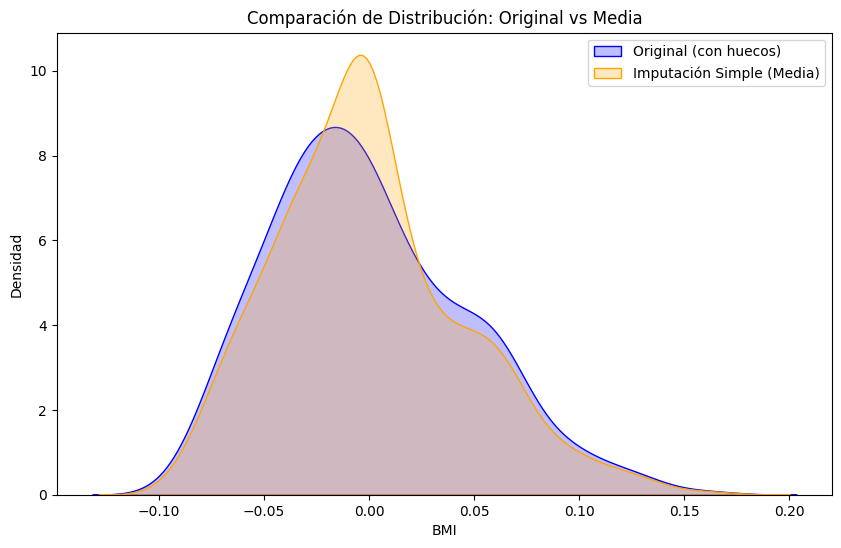

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Graficamos la distribución original (sin los NaNs)
sns.kdeplot(data['bmi'].dropna(), label='Original (con huecos)', fill=True, color="blue")

# Graficamos la distribución tras la media
sns.kdeplot(data['bmi_simple'], label='Imputación Simple (Media)', fill=True, color="orange")

plt.title('Comparación de Distribución: Original vs Media')
plt.xlabel('BMI')
plt.ylabel('Densidad')
plt.legend()
plt.show()